# Z′ $\rightarrow$ $t \bar t$: Machine Learning Analysis

## ATLAS Open Data reproduction of *Eur. Phys. J. C* **78** (2018) 565

** $ \sqrt s $  = 13 TeV, 10 fb⁻¹:  lepton + jets, boosted channel only**

A per-mass Deep Neural Network (DNN) classifier is trained to discriminate
Z′ $\rightarrow$ $t \bar t$ signal from SM backgrounds using 19 kinematic features output by the boosted event selector. The DNN score replaces the reconstructed $m_{t \bar t}$ as the fit observable. CLs limits on the signal strength $\mu$ are compared against the $m_{t \bar t}$-based baseline from `ZPrimeSUSY.ipynb` to quantify the sensitivity improvement from the multivariate approach.

| Section | Content |
|---|---|
| 1 | Imports |
| 2 | Configuration |
| 3 | Helper functions |
| 4 | Data loading |
| 5 | Data inspection and feature correlations |
| 6 | DNN training |
| 7 | Model diagnostics |
| 8 | Feature importance |
| 9 | DNN score histograms |
| 10 | DNN score stack plot |
| 11 | CLs exclusion fit (stat-only + Barlow-Beeston) |
| 12 | Comparison: $m_{t \bar t}$ vs DNN |
| 13 | Results summary |

# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import os
import math
import matplotlib.pyplot as plt
from IPython.display import Image, display

import pyhf
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

2026-06-11 13:18:26.752647: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-11 13:18:27.612488: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-11 13:18:30.757827: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Configuration

All paths, constants, sample lists, theory cross-sections, and the m_tt CLs
results (hardcoded from `ZPrimeSUSY_ipynb.ipynb` Section 12) in one place.

`LUMI = 10064 pb⁻¹`.
e
`theory_xsec` — Z′_TC2 σ×BR [pb] identical to `SIGNAL_XSEC` in the baseline notebook.

`fit_results` — 95% CL μ limits from the m_tt Barlow-Beeston CLs fit
(baseline notebook Section 12, hardcoded so this notebook runs standalone).

`N_SCORE_BINS` — number of bins for the DNN score histograms used in the CLs
fit. Defined here so it can be changed in one place.

In [2]:
CSV_DIR   = "/opt/app/atlas-open-data-code/Analysis/ZPrimeBoostedAnalysis/Output_ZPrimeBoostedAnalysis/"
FILES_TXT = "/opt/app/atlas-open-data-code/Plotting/inputfiles/Files_ZPrime.txt"
LUMI      = 10064.0   # pb^-1

FEATURES = [
    "lep_pt", "lep_eta", "lep_phi", "lep_E", "lep_charge",
    "met_et", "met_phi", "mtw",
    "smallRjet_pt", "smallRjet_eta",
    "TopLRjet_pt", "TopLRjet_eta", "TopLRjet_m", "TopLRjet_tau32",
    "bjet_pt", "bjet_eta",
    "mtt_reco", "n_jets", "n_bjets"
]

ALL_MASSES = [400, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]

# Z'_TC2 sigma*BR [pb](matches SIGNAL_XSEC in baseline notebook)
theory_xsec = {
    400: 8.99,  500: 8.74,  750: 3.12,  1000: 1.13,
    1250: 0.460, 1500: 0.207, 1750: 0.100, 2000: 0.0513,
    2250: 0.0275, 2500: 0.0152, 2750: 0.00869, 3000: 0.00508,
}

# m_tt Barlow-Beeston CLs fit results from the baseline notebook Section 12.
# 95% CL upper limits on signal strength mu.
fit_results = {
    400:  {"obs":  7.704, "exp": 10.266, "exp_m1":  7.385, "exp_p1": 14.326, "exp_m2":  5.495, "exp_p2": 19.269},
    500:  {"obs":  4.562, "exp":  6.767, "exp_m1":  4.862, "exp_p1":  9.454, "exp_m2":  3.615, "exp_p2": 12.736},
    750:  {"obs":  0.593, "exp":  0.906, "exp_m1":  0.651, "exp_p1":  1.266, "exp_m2":  0.484, "exp_p2":  1.705},
    1000: {"obs":  0.463, "exp":  0.580, "exp_m1":  0.417, "exp_p1":  0.809, "exp_m2":  0.310, "exp_p2":  1.089},
    1250: {"obs":  0.457, "exp":  0.788, "exp_m1":  0.566, "exp_p1":  1.100, "exp_m2":  0.421, "exp_p2":  1.482},
    1500: {"obs":  0.732, "exp":  1.259, "exp_m1":  0.904, "exp_p1":  1.761, "exp_m2":  0.644, "exp_p2":  2.287},
    1750: {"obs":  1.372, "exp":  2.083, "exp_m1":  1.493, "exp_p1":  2.921, "exp_m2":  1.064, "exp_p2":  3.811},
    2000: {"obs":  2.096, "exp":  3.389, "exp_m1":  2.423, "exp_p1":  4.768, "exp_m2":  1.730, "exp_p2":  6.263},
    2250: {"obs":  2.695, "exp":  5.382, "exp_m1":  3.835, "exp_p1":  7.609, "exp_m2":  2.749, "exp_p2": 10.120},
    2500: {"obs":  4.499, "exp":  8.802, "exp_m1":  6.241, "exp_p1": 12.512, "exp_m2":  4.470, "exp_p2": 16.801},
    2750: {"obs":  7.786, "exp": 14.631, "exp_m1": 10.342, "exp_p1": 20.907, "exp_m2":  7.604, "exp_p2": 28.928},
    3000: {"obs": 13.532, "exp": 25.298, "exp_m1": 17.772, "exp_p1": 36.436, "exp_m2": 13.017, "exp_p2": 50.859},
}

# background sample groups
BKG_SAMPLES = {
    "ttbar": ["ttbar_lep"],
    "W+jets": [
        "Wmunu_PTV0_70_CVetoBVeto",    "Wmunu_PTV0_70_CFilterBVeto",    "Wmunu_PTV0_70_BFilter",
        "Wmunu_PTV70_140_CVetoBVeto",  "Wmunu_PTV70_140_CFilterBVeto",  "Wmunu_PTV70_140_BFilter",
        "Wmunu_PTV140_280_CVetoBVeto", "Wmunu_PTV140_280_CFilterBVeto", "Wmunu_PTV140_280_BFilter",
        "Wmunu_PTV280_500_CVetoBVeto", "Wmunu_PTV280_500_CFilterBVeto", "Wmunu_PTV280_500_BFilter",
        "Wmunu_PTV500_1000", "Wmunu_PTV1000",
        "Wenu_PTV0_70_CVetoBVeto",     "Wenu_PTV0_70_CFilterBVeto",     "Wenu_PTV0_70_BFilter",
        "Wenu_PTV70_140_CVetoBVeto",   "Wenu_PTV70_140_CFilterBVeto",   "Wenu_PTV70_140_BFilter",
        "Wenu_PTV140_280_CVetoBVeto",  "Wenu_PTV140_280_CFilterBVeto",  "Wenu_PTV140_280_BFilter",
        "Wenu_PTV280_500_CVetoBVeto",  "Wenu_PTV280_500_CFilterBVeto",  "Wenu_PTV280_500_BFilter",
        "Wenu_PTV500_1000", "Wenu_PTV1000",
        "Wtaunu_PTV0_70_CVetoBVeto",   "Wtaunu_PTV0_70_CFilterBVeto",   "Wtaunu_PTV0_70_BFilter",
        "Wtaunu_PTV70_140_CVetoBVeto", "Wtaunu_PTV70_140_CFilterBVeto", "Wtaunu_PTV70_140_BFilter",
        "Wtaunu_PTV140_280_CVetoBVeto","Wtaunu_PTV140_280_CFilterBVeto","Wtaunu_PTV140_280_BFilter",
        "Wtaunu_PTV280_500_CVetoBVeto","Wtaunu_PTV280_500_CFilterBVeto","Wtaunu_PTV280_500_BFilter",
        "Wtaunu_PTV500_1000", "Wtaunu_PTV1000",
    ],
    "single top": [
        "single_top_tchan",  "single_antitop_tchan",
        "single_top_schan",  "single_antitop_schan",
        "single_top_wtchan", "single_antitop_wtchan",
    ],
    "Z+jets":  ["Zee", "Zmumu", "Ztautau"],
    "diboson": ["ZqqZll", "WqqZll", "WplvWmqq", "WlvZqq", "lllv", "llvv", "lvvv"],
}

# signal normalization: uniform reference scale factor from the 1 TeV cross-section.
# All mass points share this SCF for training so relative event counts are comparable.
# Physical sigma*BR limits are recovered by multiplying mu by theory_xsec.
SIGMA_REF = 1.13       # pb — Z' 1000 GeV theory xsec 
SUMW_REF  = 199800.0   # sum of weights for ZPrime1000_tt 
SCF_REF   = (LUMI * SIGMA_REF) / SUMW_REF

# DNN score histogram binning — used in CLs fit and stack plot
N_SCORE_BINS = 30
SCORE_EDGES  = np.linspace(0, 1, N_SCORE_BINS + 1)

print(f"Configuration loaded.")
print(f"  Features          : {len(FEATURES)}")
print(f"  Mass points       : {len(ALL_MASSES)}")
print(f"  Reference SCF     : {SCF_REF:.6f}")
print(f"  Score bins        : {N_SCORE_BINS}")

Configuration loaded.
  Features          : 19
  Mass points       : 12
  Reference SCF     : 0.056919
  Score bins        : 30


## 3. Helper Functions

All function definitions live here. Execution cells only call these — no
definitions appear elsewhere in the notebook.

**I/O:** `load_scale_factors`, `load_csv`

**Training:** `significance` (Asimov), `build_model` (3×Dense(100)+Dropout(0.3)),
`train_dnn_for_mass` (returns val + test AUC, full training history)

**Histogramming:** `make_score_hist`, `get_dnn_scores_for_sample`

**Fitting:** `run_cls_fit_np` (stat-only or Barlow-Beeston via `b_err_arr`)

In [3]:
# I/O helpers 

def load_scale_factors(filepath, lumi):
    """Read Files_ZPrime.txt and compute per-sample scale factors.
    scf = (lumi * xsec) / (sumw * eff). Data gets scf = 1.0."""
    sf = {}
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split("|")
            if len(parts) < 4:
                continue
            name = parts[0].strip()
            xsec = float(parts[1].strip())
            sumw = float(parts[2].strip())
            eff  = float(parts[3].strip())
            if "data" in name.lower():
                sf[name] = 1.0
            else:
                sumw_eff = sumw * eff
                sf[name] = (lumi * xsec) / sumw_eff if sumw_eff != 0 else 1.0
    return sf


def load_csv(sample_name, scf=None):
    """Load a per-event CSV and apply luminosity scale factor."""
    path = os.path.join(CSV_DIR, sample_name + ".csv")
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    if len(df) == 0:
        return None
    df = df.dropna(subset=FEATURES)   # drop rows with NaN from neutrino reco edge cases
    if scf is not None and scf != 1.0:
        df["weight"] = df["weight"] * scf
    return df


# training helpers 

def significance(s, b):
    """Asimov significance: sqrt(2*((s+b)*ln(1+s/b) - s))."""
    if b <= 0 or s <= 0:
        return 0
    sig = math.sqrt(2 * (s + b) * math.log(1 + s / b) - 2 * s)
    return sig if not (math.isnan(sig) or math.isinf(sig)) else 0


def build_model(n_features):
    """Three hidden layers of 100 neurons with ReLU + Dropout(0.3) regularization."""
    model = Sequential()
    model.add(Dense(100, input_dim=n_features, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(100, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(100, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=1e-3),
        weighted_metrics=['accuracy']
    )
    return model


def train_dnn_for_mass(mass, df_bkg, df_sig, features):
    """Train one per-mass DNN binary classifier.

    Returns a dict with: model, scaler, history, auc (test), auc_val,
    max_sig, fpr, tpr, data (full dataset with y_pred column).
    """
    print(f"\n{'='*55}")
    print(f"  Training DNN for Z' {mass} GeV")
    print(f"{'='*55}")

    sig = df_sig.copy();  sig['label'] = 1
    bkg = df_bkg.copy();  bkg['label'] = 0
    sig['scale_weight'] = sig['weight']
    bkg['scale_weight'] = bkg['weight']
    data = pd.concat([sig, bkg], ignore_index=True)

    print(f"  Signal expected    : {data.query('label==1')['scale_weight'].sum():.1f} events")
    print(f"  Background expected: {data.query('label==0')['scale_weight'].sum():.1f} events")

    # normalize signal and background to 1:1 for training
    data['train_weight'] = 1.0
    sig_idx = data.query('label==1').index
    bkg_idx = data.query('label==0').index
    data.loc[sig_idx, 'train_weight'] = (
        data.loc[sig_idx, 'scale_weight'] / data.loc[sig_idx, 'scale_weight'].sum()
    )
    data.loc[bkg_idx, 'train_weight'] = (
        data.loc[bkg_idx, 'scale_weight'] / data.loc[bkg_idx, 'scale_weight'].sum()
    )

    # 3-way split: 1/3 train, 1/3 val, 1/3 test
    X = data[features].values
    y = data['label'].values
    w = data['train_weight'].values
    X_train, X_tmp, y_train, y_tmp, w_train, w_tmp = train_test_split(
        X, y, w, train_size=1/3, random_state=9
    )
    X_val, X_test, y_val, y_test, w_val, w_test = train_test_split(
        X_tmp, y_tmp, w_tmp, test_size=1/2, random_state=9
    )

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    model = build_model(n_features=len(features))
    history = model.fit(
        X_train, y_train,
        sample_weight=w_train,
        validation_data=(X_val, y_val, w_val),
        epochs=200,
        batch_size=1024,
        callbacks=EarlyStopping(patience=10, restore_best_weights=True),
        verbose=0
    )
    n_epochs = len(history.history['loss'])
    print(f"  Stopped at epoch  : {n_epochs}")
    print(f"  Final val loss    : {history.history['val_loss'][-1]:.4f}")

    # AUC on validation set (for reference) and held-out test set (true metric)
    y_val_pred  = model.predict(X_val,  verbose=0).flatten()
    y_test_pred = model.predict(X_test, verbose=0).flatten()
    fpr, tpr, _ = roc_curve(y_test, y_test_pred)
    auc_val     = roc_auc_score(y_val,  y_val_pred)
    auc_test    = roc_auc_score(y_test, y_test_pred)
    print(f"  Val AUC           : {auc_val:.4f}")
    print(f"  Test AUC          : {auc_test:.4f}  (held-out)")

    # significance scan on full dataset
    data['y_pred'] = model.predict(
        scaler.transform(data[features].values), verbose=0
    ).flatten()
    cuts = np.linspace(0, 1, 20)
    sigs = []
    for cut in cuts:
        s = data.loc[data.query(f'label==1 & y_pred>{cut}').index, 'scale_weight'].sum()
        b = data.loc[data.query(f'label==0 & y_pred>{cut}').index, 'scale_weight'].sum()
        sigs.append(significance(s, b))
    max_sig = max(sigs)
    print(f"  Max significance  : {max_sig:.3f}")

    return {
        "model":   model,
        "scaler":  scaler,
        "history": history.history,
        "auc":     auc_test,
        "auc_val": auc_val,
        "max_sig": max_sig,
        "fpr":     fpr,
        "tpr":     tpr,
        "data":    data,
    }


# histogram helpers 

def make_score_hist(name, values, weights, edges):
    """Weighted histogram of DNN scores.
    Returns (counts, errors) where errors[i] = sqrt(sum_w2_i)."""
    counts,    _ = np.histogram(values, bins=edges, weights=weights)
    counts_sq, _ = np.histogram(values, bins=edges, weights=weights**2)
    return counts, np.sqrt(counts_sq)


def get_dnn_scores_for_sample(df, mass):
    """Apply the mass-specific DNN to a dataframe and return score array."""
    model  = results[mass]["model"]
    scaler = results[mass]["scaler"]
    X = scaler.transform(df[FEATURES].values)
    return model.predict(X, verbose=0).flatten()


# CLs fit 

def run_cls_fit_np(s_arr, b_arr, n_arr, b_err_arr=None, n_scan=150):
    """CLs scan on numpy histogram arrays.

    Parameters
    ----------
    s_arr     : signal counts per bin
    b_arr     : background counts per bin
    n_arr     : observed data counts per bin
    b_err_arr : MC statistical errors per bin (sqrt sum_w2).
                If provided, adds Barlow-Beeston staterror nuisances.
    n_scan    : number of mu points in the scan

    Returns
    -------
    obs_lim  : observed 95% CL upper limit on mu
    exp_lims : list of 5 expected quantiles [-2s, -1s, median, +1s, +2s]
    """
    keep = b_arr > 0
    s, b, n = s_arr[keep], b_arr[keep], n_arr[keep]
    b_err = b_err_arr[keep] if b_err_arr is not None else None

    if s.sum() < 1e-6:
        return 1e3, [1e3] * 5

    if b_err is not None:
        spec = {"channels": [{"name": "SR", "samples": [
            {"name": "signal",     "data": [float(x) for x in s],
             "modifiers": [{"name": "mu", "type": "normfactor", "data": None}]},
            {"name": "background", "data": [float(x) for x in b],
             "modifiers": [{"name": "mcstat", "type": "staterror",
                            "data": [float(x) for x in b_err]}]},
        ]}]}
    else:
        spec = {"channels": [{"name": "SR", "samples": [
            {"name": "signal",     "data": [float(x) for x in s],
             "modifiers": [{"name": "mu", "type": "normfactor", "data": None}]},
            {"name": "background", "data": [float(x) for x in b],
             "modifiers": []},
        ]}]}

    model = pyhf.Model(spec, poi_name="mu")
    data  = list(n) + model.config.auxdata

    fisher     = float(np.sum(s**2 / b))
    mu_est     = 1.64 / np.sqrt(fisher) if fisher > 0 else 100.0
    mu_hi      = max(6.0 * mu_est, 2.0)
    scan       = np.linspace(0.0, mu_hi, n_scan)[1:]
    init_pars  = model.config.suggested_init()
    par_bounds = model.config.suggested_bounds()
    par_bounds[model.config.poi_index] = (0.0, max(mu_hi * 1.1, 5.0))

    obs_cls, exp_cls = [], [[], [], [], [], []]
    for poi in scan:
        try:
            result = pyhf.infer.hypotest(
                poi, data, model,
                test_stat="qtilde",
                return_expected_set=True,
                init_pars=init_pars,
                par_bounds=par_bounds,
            )
            obs_cls.append(float(result[0]))
            for qi in range(5): exp_cls[qi].append(float(result[1][qi]))
        except Exception:
            obs_cls.append(np.nan)
            for qi in range(5): exp_cls[qi].append(np.nan)

    obs_cls = np.array(obs_cls)
    exp_cls = [np.array(q) for q in exp_cls]

    def crossing(mu_scan, cls):
        good = np.isfinite(cls)
        mu_g, cls_g = mu_scan[good], cls[good]
        if len(cls_g) < 2: return float(mu_scan[-1])
        for i in range(len(cls_g) - 1):
            if cls_g[i] >= 0.05 >= cls_g[i + 1]:
                f = (cls_g[i] - 0.05) / (cls_g[i] - cls_g[i + 1])
                return float(mu_g[i] + f * (mu_g[i + 1] - mu_g[i]))
        if cls_g[0] < 0.05: return float(mu_g[0])
        return float(mu_scan[-1])

    return crossing(scan, obs_cls), [crossing(scan, exp_cls[qi]) for qi in range(5)]


print("All helper functions defined.")

All helper functions defined.


## 4. Data Loading

Load all per-event CSV files produced by `ZPrimeBoostedAnalysis.C`. Each row
is one event passing the full boosted selection which are the same events that fill `hist_ttbarMLR` in the baseline notebook.

The `weight` column contains `scaleFactor × mcWeight`. We multiply by
`scf = lumi × xsec / (sumw × eff)` from `Files_ZPrime.txt` to get expected
events at 10 fb⁻¹.

Signal uses a uniform reference scale factor (`SCF_REF` from 1 TeV) so all
mass points have comparable raw event counts for training. Physical σ×BR
limits are recovered in the comparison plot by multiplying μ by `theory_xsec`.

The 0.91 tt̄ correction is applied when building fit histograms (Section 9),
not here, so training uses uncorrected raw MC weights.

In [4]:
SCALE_FACTORS = load_scale_factors(FILES_TXT, LUMI)

#  load all backgrounds 
bkg_frames = []
for group, samples in BKG_SAMPLES.items():
    for s in samples:
        scf = SCALE_FACTORS.get(s, None)
        df  = load_csv(s, scf)
        if df is not None:
            df["group"] = group
            df["label"] = 0
            bkg_frames.append(df)

df_bkg = pd.concat(bkg_frames, ignore_index=True)

# load all signals 
sig_frames = {}
for mass in ALL_MASSES:
    df = load_csv(f"ZPrime{mass}_tt", SCF_REF)
    if df is not None:
        df["mass"]  = mass
        df["label"] = 1
        sig_frames[mass] = df

# summary 
print("Background summary (weighted events):\n")
total_bkg = 0
for group in BKG_SAMPLES:
    n = df_bkg[df_bkg["group"] == group]["weight"].sum()
    total_bkg += n
    print(f"  {group:<15}  {n:>10,.1f}")
print(f"  {'-'*28}")
print(f"  {'Total bkg':<15}  {total_bkg:>10,.1f}")

print("\nSignal summary (weighted events at SCF_REF):\n")
for mass, df in sig_frames.items():
    print(f"  Z' {mass:>4} GeV   {df['weight'].sum():>8.1f} events")

print("\nAll data loaded successfully.")

Background summary (weighted events):

  ttbar               8,936.5
  W+jets                174.8
  single top            313.6
  Z+jets                  1.0
  diboson                 7.0
  ----------------------------
  Total bkg           9,433.0

Signal summary (weighted events at SCF_REF):

  Z'  400 GeV        2.2 events
  Z'  500 GeV        3.1 events
  Z'  750 GeV       60.8 events
  Z' 1000 GeV      291.3 events
  Z' 1250 GeV      420.0 events
  Z' 1500 GeV      453.4 events
  Z' 1750 GeV      425.3 events
  Z' 2000 GeV      390.4 events
  Z' 2250 GeV      351.1 events
  Z' 2500 GeV      309.7 events
  Z' 2750 GeV      266.7 events
  Z' 3000 GeV      225.2 events

All data loaded successfully.


## 5. Data Inspection and Feature Correlations

Verify the loaded dataframes are physical and sensible before training.

Expected ranges:
- `lep_pt`, `met_et`, `mtw`: in GeV 
- `TopLRjet_pt`: always > 300 GeV (boosted selection cut)
- `TopLRjet_tau32`: between 0 and 0.75 (top-tagging cut)
- `lep_charge`: ±1 integer
- `n_jets`, `n_bjets`: small integers (typically 1–5)

The correlation matrix shows linear relationships between features. Highly
correlated pairs (e.g. `lep_pt` / `lep_E`, `n_jets` / `n_bjets`) carry redundant information, the DNN must learn to exploit their combined discriminating power rather than relying on any single feature.

Background dataframe shape: (124796, 22)

Feature ranges (background):

           lep_pt   lep_eta   lep_phi        lep_E  lep_charge       met_et   met_phi          mtw  smallRjet_pt  smallRjet_eta  TopLRjet_pt  TopLRjet_eta  TopLRjet_m  TopLRjet_tau32      bjet_pt  bjet_eta    mtt_reco    n_jets   n_bjets
min     30.000500 -2.494800 -3.141540    30.114800   -1.000000    20.002100 -3.141570     0.000679     30.000800      -2.499710   300.001000     -1.999980   100.00100       -1.000000    30.000900 -2.499560   395.27200  1.000000  1.000000
mean   122.599371 -0.004015  0.014541   199.587473    0.037325   142.622585  0.002649    64.972352    184.613486      -0.002917   428.012661     -0.003155   157.69906        0.513088   220.670353 -0.003326  1125.77967  1.568608  1.643923
max   2009.830000  2.478710  3.141490  3722.230000    1.000000  5360.820000  3.141500  2391.570000   2174.780000       2.499380  1498.070000      1.999930   778.88500        0.749996  2174.780000  2.499380  6111.15

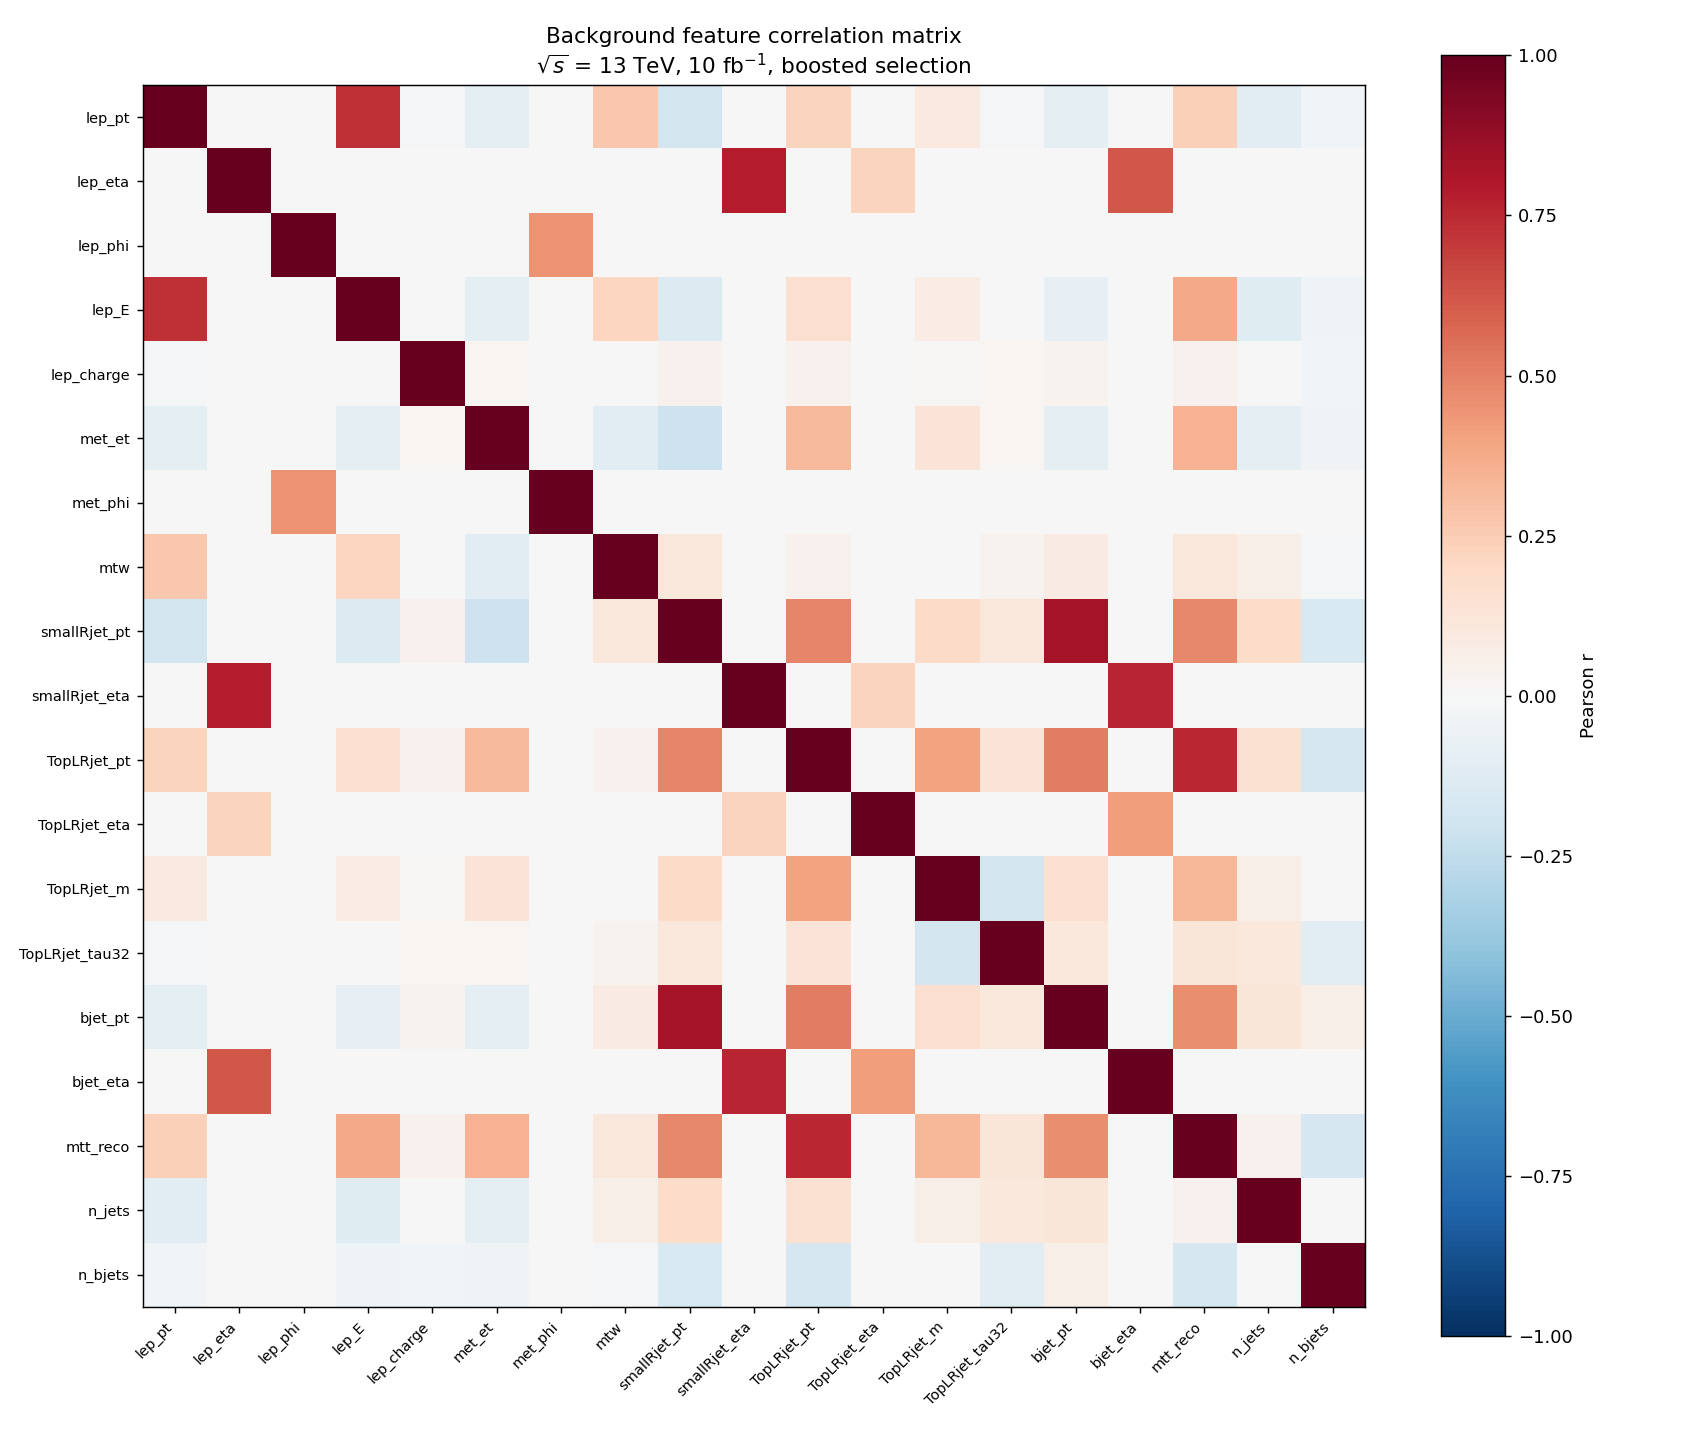

In [5]:
# sanity checks 
print("Background dataframe shape:", df_bkg.shape)
print("\nFeature ranges (background):\n")
print(df_bkg[FEATURES].describe().loc[["min", "mean", "max"]].to_string())
print("\nSample of ttbar events:")
print(df_bkg[df_bkg["group"] == "ttbar"][FEATURES].head(3).to_string())
print("\nSample of ZPrime1500 events:")
print(sig_frames[1500][FEATURES].head(3).to_string())

# feature correlation matrix 

corr = df_bkg[FEATURES].corr()
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels(FEATURES, fontsize=8)
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Background feature correlation matrix\n"  r"$\sqrt{s}$ = 13 TeV, 10 fb$^{-1}$, boosted selection", fontsize=12)
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=130)
plt.close()
display(Image("feature_correlation.png", width=850))

## 6. DNN Training

One binary classifier is trained per Z′ mass hypothesis (a **per-mass DNN**).
Each DNN learns the specific kinematic signature of its target mass against all
SM backgrounds, rather than a generic resonance-vs-background classifier. This
allows the network to exploit mass-dependent kinematics such as the boost of
the hadronic top at high mass.

### Architecture


```
Input (19 features) → Dense(100, ReLU) → Dropout(0.3)
                    → Dense(100, ReLU) → Dropout(0.3)
                    → Dense(100, ReLU) → Dropout(0.3)
                    → Dense(1, sigmoid)
```
Dropout (rate 0.3) is applied after each hidden layer to reduce overfitting,
particularly at low masses (400–750 GeV) where signal and background shapes
are similar and the network could memorize training-set fluctuations.

### Weight normalization

Signal is far rarer than background (~300–9400 weighted events depending on
mass). We normalize `train_weight` so that the total signal weight equals the
total background weight (1:1 ratio), preventing the DNN from learning to
always predict background.

### Training protocol

- **Split:** 1/3 train, 1/3 validation, 1/3 test (`random_state=9`)
- **Scaler:** `StandardScaler` fit on train, applied to val and test
- **Optimizer:** Adam, learning rate 1×10⁻³
- **Epochs:** up to 200 with `EarlyStopping(patience=10, restore_best_weights=True)`
- **Batch size:** 1024
- **AUC:** reported on the held-out test set (not the validation set used for early stopping)


In [6]:
results = {}
for mass in ALL_MASSES:
    if mass not in sig_frames:
        print(f"Skipping Z' {mass} GeV — no CSV found")
        continue
    results[mass] = train_dnn_for_mass(mass, df_bkg, sig_frames[mass], FEATURES)

print("\n\n Training Summary")
print(f"  {'mass':>6}   {'AUC (test)':>10}   {'AUC (val)':>9}   {'max sig':>10}   {'epochs':>7}")
print("  " + "-"*54)
for mass, r in results.items():
    print(f"  {mass:>6} GeV   {r['auc']:>10.4f}   {r['auc_val']:>9.4f}"
          f"   {r['max_sig']:>10.3f}   {len(r['history']['loss']):>7}")


  Training DNN for Z' 400 GeV
  Signal expected    : 2.2 events
  Background expected: 9433.0 events


/usr/local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-11 13:18:34.010232: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  Stopped at epoch  : 11
  Final val loss    : 0.0000
  Val AUC           : 0.6288
  Test AUC          : 0.5387  (held-out)
  Max significance  : 0.022

  Training DNN for Z' 500 GeV
  Signal expected    : 3.1 events
  Background expected: 9433.0 events


/usr/local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Stopped at epoch  : 13
  Final val loss    : 0.0000
  Val AUC           : 0.6577
  Test AUC          : 0.4858  (held-out)
  Max significance  : 0.032

  Training DNN for Z' 750 GeV
  Signal expected    : 60.8 events
  Background expected: 9433.0 events


...

  Stopped at epoch  : 59
  Final val loss    : 0.0000
  Val AUC           : 0.9448
  Test AUC          : 0.9450  (held-out)
  Max significance  : 14.767

  Training DNN for Z' 2750 GeV
  Signal expected    : 266.7 events
  Background expected: 9433.0 events


/usr/local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Stopped at epoch  : 55
  Final val loss    : 0.0000
  Val AUC           : 0.9486
  Test AUC          : 0.9462  (held-out)
  Max significance  : 14.771

  Training DNN for Z' 3000 GeV
  Signal expected    : 225.2 events
  Background expected: 9433.0 events


/usr/local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Stopped at epoch  : 50
  Final val loss    : 0.0000
  Val AUC           : 0.9444
  Test AUC          : 0.9454  (held-out)
  Max significance  : 13.683


 Training Summary
    mass   AUC (test)   AUC (val)      max sig    epochs
  ------------------------------------------------------
     400 GeV       0.5387      0.6288        0.022        11
     500 GeV       0.4858      0.6577        0.032        13
     750 GeV       0.7778      0.7763        0.841        38
    1000 GeV       0.7889      0.7920        4.036       105
    1250 GeV       0.8526      0.8477        7.357       112
    1500 GeV       0.8857      0.8916       10.228       150
    1750 GeV       0.9122      0.9135       11.731       164
    2000 GeV       0.9239      0.9233       12.774        83
    2250 GeV       0.9357      0.9336       13.940        49
    2500 GeV       0.9450      0.9448       14.767        59
    2750 GeV       0.9462      0.9486       14.771        55
    3000 GeV       0.9454      0.9444     

## 7. Model Diagnostics

Four panels per selected mass point:

**Loss curves**: training and validation loss vs epoch. With Dropout,
training loss may sit above validation loss at intermediate epochs; this
is expected and is not a sign of underfitting. `EarlyStopping` when validation loss stops improving.

**DNN output distributions**: signal (red) and background (blue) score
distributions on the full dataset (normalized to unit area). Good separation
means background peaks near 0 and signal peaks near 1. Separation sharpens
with increasing mass as the boosted topology becomes more distinct from tt̄.

**ROC curve**: TPR vs FPR on the held-out test set. AUC > 0.9 at high mass
shows the DNN extracts kinematic information beyond $m_{t \bar t}$ alone.

**Significance vs DNN cut**: Asimov significance
$ Z = \sqrt {2[(s+b)\ln(1+s/b) − s]} $  as a function of the DNN output threshold. The peak gives the optimal working point for a simple cut-based analysis.

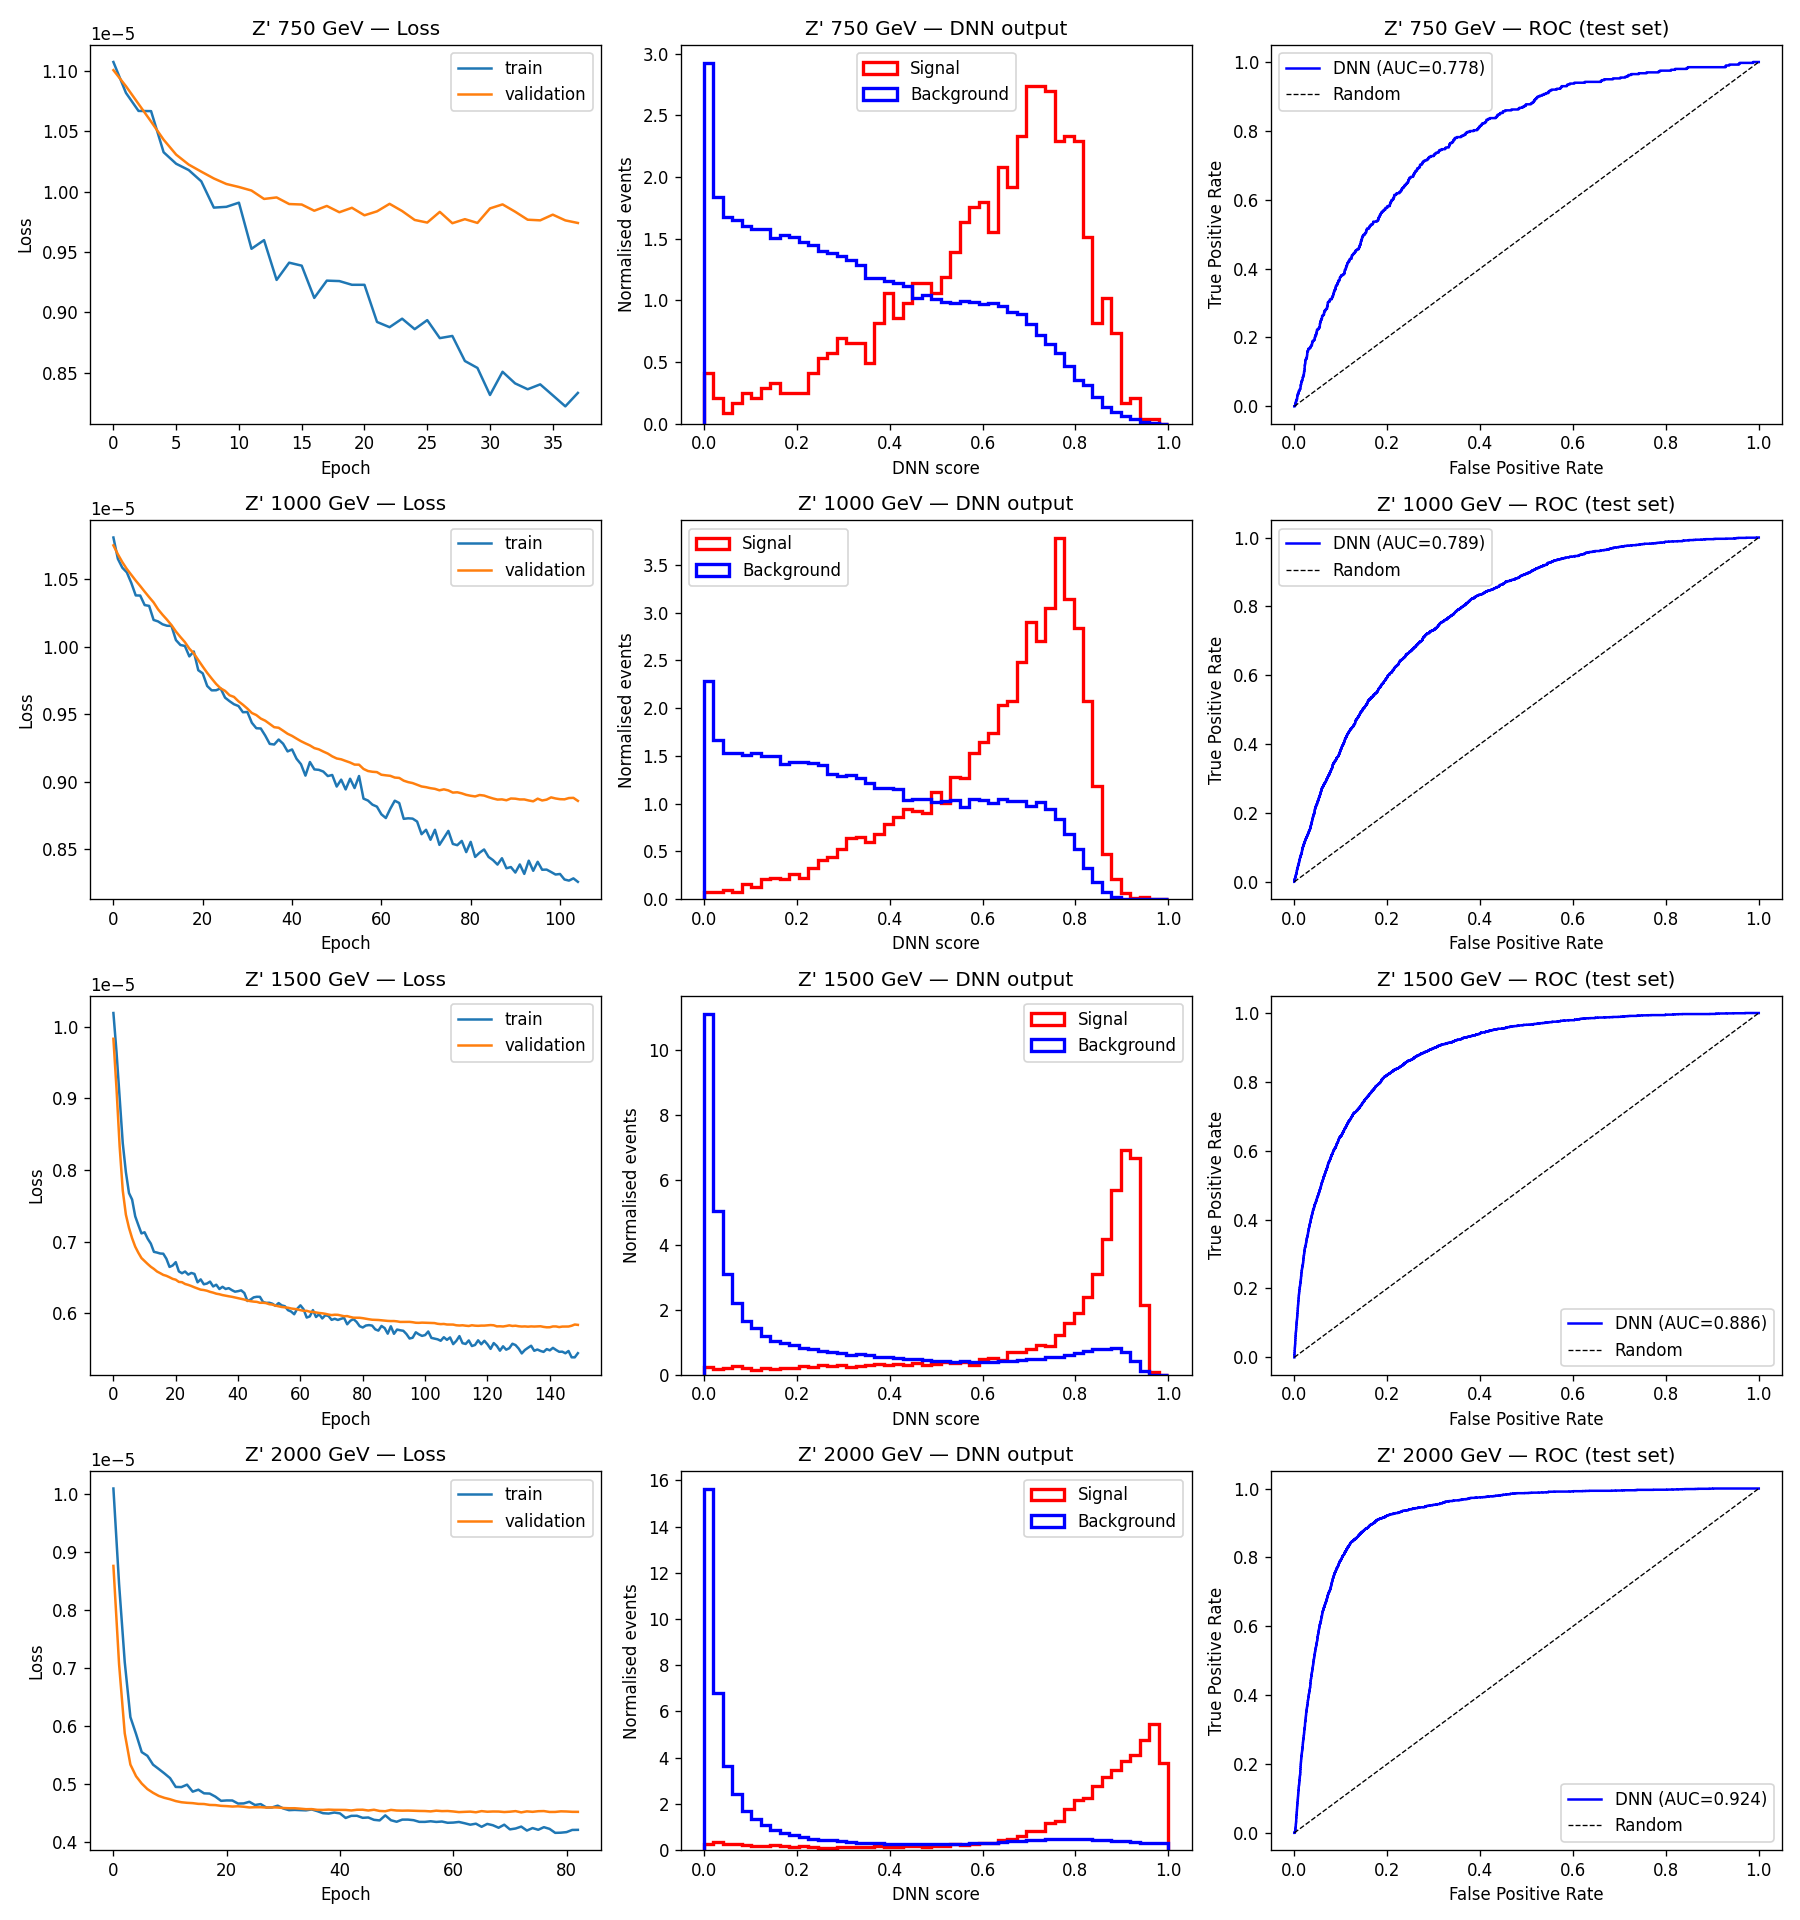

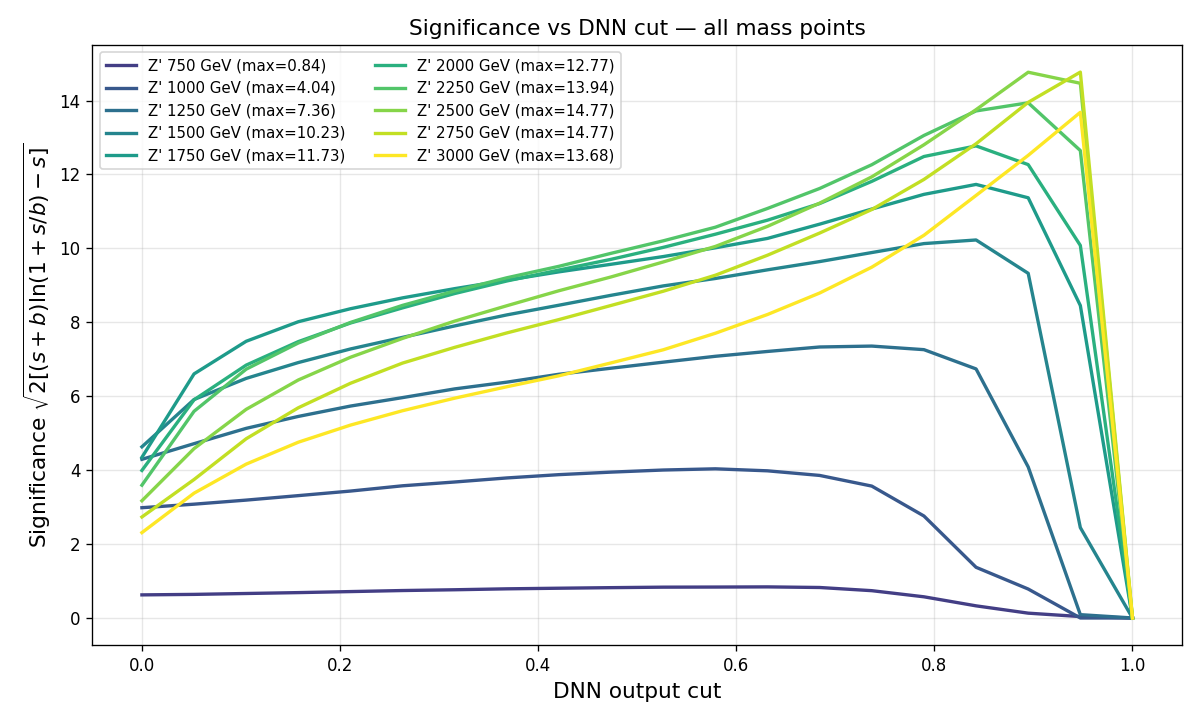

In [7]:
selected_masses = [750, 1000, 1500, 2000]

fig, axes = plt.subplots(len(selected_masses), 3, figsize=(15, 4 * len(selected_masses)))

for row, mass in enumerate(selected_masses):
    r = results[mass]

    # col 0: loss curves
    ax = axes[row, 0]
    ax.plot(r["history"]["loss"],     label="train")
    ax.plot(r["history"]["val_loss"], label="validation")
    ax.set_title(f"Z' {mass} GeV — Loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()

    # col 1: DNN output distributions
    ax = axes[row, 1]
    data = r["data"]
    bins = np.linspace(0, 1, 50)
    ax.hist(data.loc[data["label"] == 1, "y_pred"].values,
            bins=bins, density=True, histtype="step",
            color="red",  lw=2, label="Signal")
    ax.hist(data.loc[data["label"] == 0, "y_pred"].values,
            bins=bins, density=True, histtype="step",
            color="blue", lw=2, label="Background")
    ax.set_title(f"Z' {mass} GeV — DNN output")
    ax.set_xlabel("DNN score"); ax.set_ylabel("Normalised events"); ax.legend()

    # col 2: ROC curve (test set)
    ax = axes[row, 2]
    ax.plot(r["fpr"], r["tpr"], color="blue",
            label=f"DNN (AUC={r['auc']:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Random")
    ax.set_title(f"Z' {mass} GeV — ROC (test set)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate"); ax.legend()

plt.tight_layout()
plt.savefig("dnn_diagnostics.png", dpi=120)
plt.close()
display(Image("dnn_diagnostics.png", width=1000))

# significance vs DNN cut for all masses with sensitivity > 0.1
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(results)))

for (mass, r), color in zip(results.items(), colors):
    if r["max_sig"] < 0.1:
        continue
    data  = r["data"]
    cuts  = np.linspace(0, 1, 20)
    sigs  = []
    for cut in cuts:
        s = data.loc[data.query(f'label==1 & y_pred>{cut}').index, 'scale_weight'].sum()
        b = data.loc[data.query(f'label==0 & y_pred>{cut}').index, 'scale_weight'].sum()
        sigs.append(significance(s, b))
    ax.plot(cuts, sigs, color=color, lw=2,
            label=f"Z' {mass} GeV (max={max(sigs):.2f})")

ax.set_xlabel("DNN output cut", fontsize=13)
ax.set_ylabel(r"Significance $\sqrt{2[(s+b)\ln(1+s/b)-s]}$", fontsize=13)
ax.set_title("Significance vs DNN cut — all mass points", fontsize=13)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("dnn_significance.png", dpi=120)
plt.close()
display(Image("dnn_significance.png", width=900))

## 8. Feature Importance

Permutation importance measures the dependence of each trained DNN on its
input features. For each feature in turn, that column is randomly shuffled
across all events, breaking its correlation with the label and the
resulting drop in test-set AUC is recorded. A large drop means the model
relies heavily on that feature; near-zero drop means it is ignored or
replaced by a correlated surrogate.

Results are shown for the **1000 GeV** (excluded in baseline) and **1500 GeV**
(borderline in baseline) hypotheses, where the DNN provides the most
physics-relevant discrimination. Comparing the two panels reveals which
features the network up-weights as signal becomes more boosted and kinematically distinct from $t \bar t$ background.

Computing permutation importance for Z' 1000 GeV (n_repeats=3)...


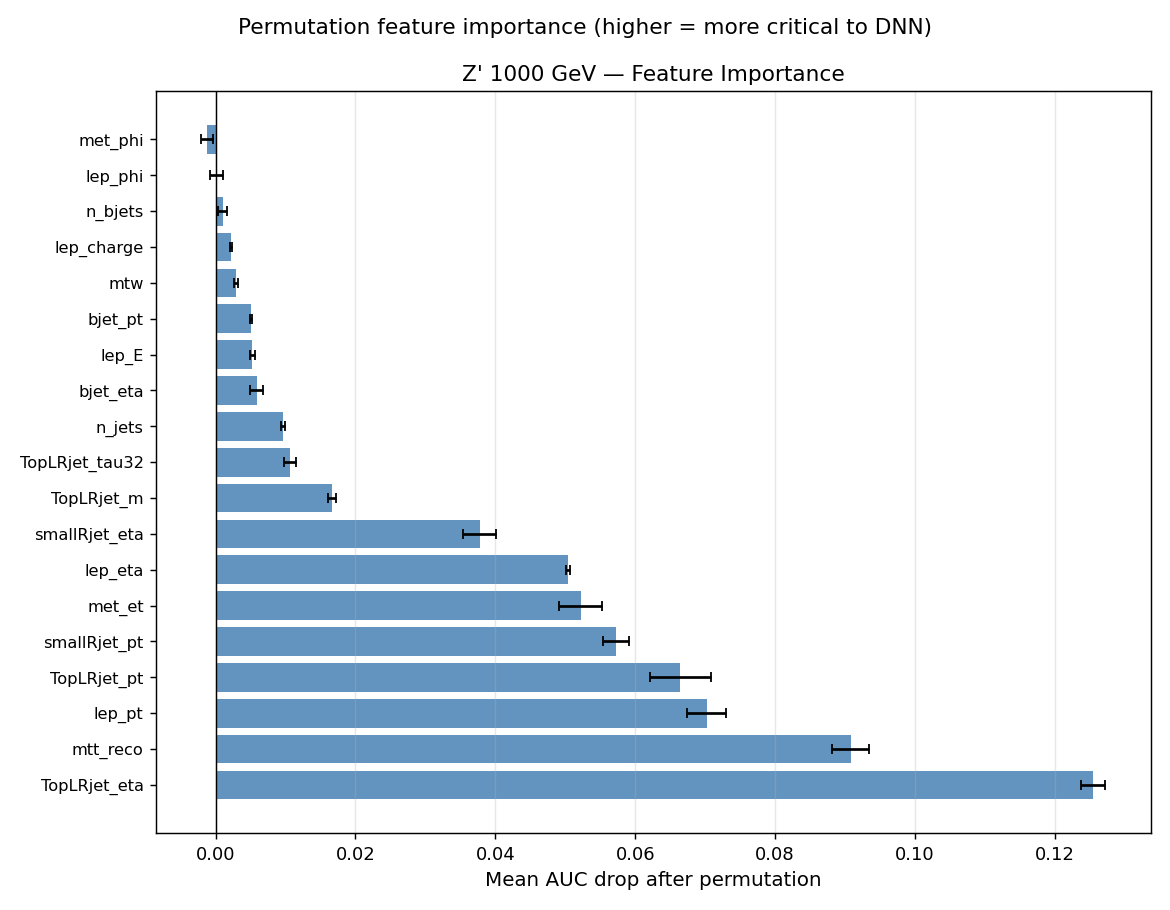

In [14]:
def compute_perm_importance(mass, n_repeats=10):
    """Permutation importance for one mass hypothesis.
    Shuffles each feature n_repeats times and records the AUC drop.
    Uses the held-out test portion of the training data.
    """
    r      = results[mass]
    model  = r["model"]
    scaler = r["scaler"]
    data   = r["data"]

    # rebuild the same test split as in train_dnn_for_mass
    X = data[FEATURES].values
    y = data["label"].values
    _, X_tmp, _, y_tmp = train_test_split(X, y, train_size=1/3, random_state=9)
    _, X_test, _, y_test = train_test_split(X_tmp, y_tmp, test_size=1/2, random_state=9)
    X_test_sc = scaler.transform(X_test)

    baseline_auc = roc_auc_score(y_test, model.predict(X_test_sc, verbose=0).flatten())

    means, stds = [], []
    for fi in range(len(FEATURES)):
        drops = []
        for _ in range(n_repeats):
            X_perm = X_test_sc.copy()
            np.random.shuffle(X_perm[:, fi])
            perm_auc = roc_auc_score(
                y_test, model.predict(X_perm, verbose=0).flatten()
            )
            
            drops.append(baseline_auc - perm_auc)
        means.append(np.mean(drops))
        stds.append(np.std(drops))

    return np.array(means), np.array(stds)

print("Computing permutation importance for Z' 1000 GeV (n_repeats=3)...")
means, stds = compute_perm_importance(1000, n_repeats=3)
order = np.argsort(means)[::-1]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(range(len(FEATURES)), means[order], xerr=stds[order],
        color="steelblue", alpha=0.85, capsize=3)
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels([FEATURES[i] for i in order], fontsize=9)
ax.set_xlabel("Mean AUC drop after permutation", fontsize=11)
ax.set_title("Z' 1000 GeV — Feature Importance", fontsize=12)
ax.axvline(0, color="black", lw=0.8)
ax.grid(True, axis="x", alpha=0.3)

plt.suptitle("Permutation feature importance (higher = more critical to DNN)",
             fontsize=12)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=130)
plt.close()
display(Image("feature_importance.png", width=800))

## 9. DNN Score Histograms

Apply each mass-specific DNN to all samples (signal, all backgrounds, data)
and bin the output score into `N_SCORE_BINS` equal bins over [0, 1]. This
produces the direct analogue of `hist_ttbarMLR` but using the DNN score as
the fit observable.

The 0.91 $t \bar t$ correction from `Plotting.C` is applied here when building the background histogram, consistent with the baseline notebook, so the background yield is identical between the two fits.

`make_score_hist` tracks MC statistical uncertainties per bin
(errors[i] = $\sqrt{\sum w_{i}^2}$, accumulated in quadrature across background samples
into `dnn_bkg_errs` for the Barlow-Beeston fit in Section 11.

In [9]:
#  load data CSV 
df_data = load_csv("data", scf=1.0)

#  build histograms for each mass 
dnn_sig_hists = {}    # mass -> signal score histogram (counts)
dnn_bkg_hists = {}    # mass -> total background score histogram (counts)
dnn_bkg_errs  = {}    # mass -> total background MC stat errors (sqrt sum_w2)
dnn_dat_hists = {}    # mass -> data score histogram (integer counts)

for mass in ALL_MASSES:
    if mass not in results:
        continue

    print(f"Building score histograms for Z' {mass} GeV...", end=" ")

    # signal
    phys_scf = (LUMI * theory_xsec[mass]) / SUMW_REF
    df_s     = load_csv(f"ZPrime{mass}_tt", phys_scf)
    scores_s = get_dnn_scores_for_sample(df_s, mass)
    dnn_sig_hists[mass], _ = make_score_hist(
        f"sig_{mass}", scores_s, df_s["weight"].values, SCORE_EDGES
    )

    # background: accumulate counts and variances across all groups
    bkg_total = np.zeros(N_SCORE_BINS)
    bkg_var   = np.zeros(N_SCORE_BINS)
    for group, samples in BKG_SAMPLES.items():
        for s in samples:
            scf  = SCALE_FACTORS.get(s, None)
            df_b = load_csv(s, scf)
            if df_b is None:
                continue
            if s == "ttbar_lep":
                df_b["weight"] *= 0.91   # same correction as baseline notebook
            scores_b = get_dnn_scores_for_sample(df_b, mass)
            counts_b, errors_b = make_score_hist(
                f"bkg_{s}", scores_b, df_b["weight"].values, SCORE_EDGES
            )
            bkg_total += counts_b
            bkg_var   += errors_b**2     # accumulate variances

    dnn_bkg_hists[mass] = bkg_total
    dnn_bkg_errs[mass]  = np.sqrt(bkg_var)

    # data (unit weights)
    scores_d = get_dnn_scores_for_sample(df_data, mass)
    dnn_dat_hists[mass], _ = make_score_hist(
        f"dat_{mass}", scores_d, np.ones(len(df_data)), SCORE_EDGES
    )

    print(f"sig={dnn_sig_hists[mass].sum():.1f}  "
          f"bkg={dnn_bkg_hists[mass].sum():.1f}  "
          f"data={dnn_dat_hists[mass].sum():.0f}  "
          f"bkg_err_max={dnn_bkg_errs[mass].max():.2f}")

print("\nDone.")

Building score histograms for Z' 400 GeV... sig=17.2  bkg=8628.7  data=8475  bkg_err_max=17.04
Building score histograms for Z' 500 GeV... sig=23.8  bkg=8628.7  data=8475  bkg_err_max=11.74
Building score histograms for Z' 750 GeV... sig=167.7  bkg=8628.7  data=8475  bkg_err_max=6.33
Building score histograms for Z' 1000 GeV... sig=291.3  bkg=8628.7  data=8475  bkg_err_max=6.19
Building score histograms for Z' 1250 GeV... sig=171.0  bkg=8628.7  data=8475  bkg_err_max=9.73
Building score histograms for Z' 1500 GeV... sig=83.1  bkg=8628.7  data=8475  bkg_err_max=16.11
Building score histograms for Z' 1750 GeV... sig=37.6  bkg=8628.7  data=8475  bkg_err_max=19.93
Building score histograms for Z' 2000 GeV... sig=17.7  bkg=8628.7  data=8475  bkg_err_max=19.25
Building score histograms for Z' 2250 GeV... sig=8.5  bkg=8628.7  data=8475  bkg_err_max=19.87
Building score histograms for Z' 2500 GeV... sig=4.2  bkg=8628.7  data=8475  bkg_err_max=17.77
Building score histograms for Z' 2750 GeV... 

## 10. DNN Score Stack Plot

The DNN score distribution for signal and stacked backgrounds at the 1000 GeV
mass hypothesis, overlaid with data. This is the direct analogue of the
m_tt stacked plot in the baseline notebook, it shows the actual fit observable before fitting and validates that the background model describes the data in score space.

Signal events cluster near score = 1; background events cluster near score = 0. The Data/MC ratio panel checks that the background model describes the data
across the full score range. Systematic deviations in the ratio at high scores
(the signal-enriched region) would indicate the DNN has learned a feature the
MC describes poorly.

/tmp/ipykernel_74069/2530289709.py:63: RuntimeWarning: invalid value encountered in divide
  ratio     = np.where(bkg_total_hist > 0, dat_h / bkg_total_hist, np.nan)
/tmp/ipykernel_74069/2530289709.py:64: RuntimeWarning: invalid value encountered in divide
  ratio_err = np.where(bkg_total_hist > 0, np.sqrt(dat_h) / bkg_total_hist, np.nan)


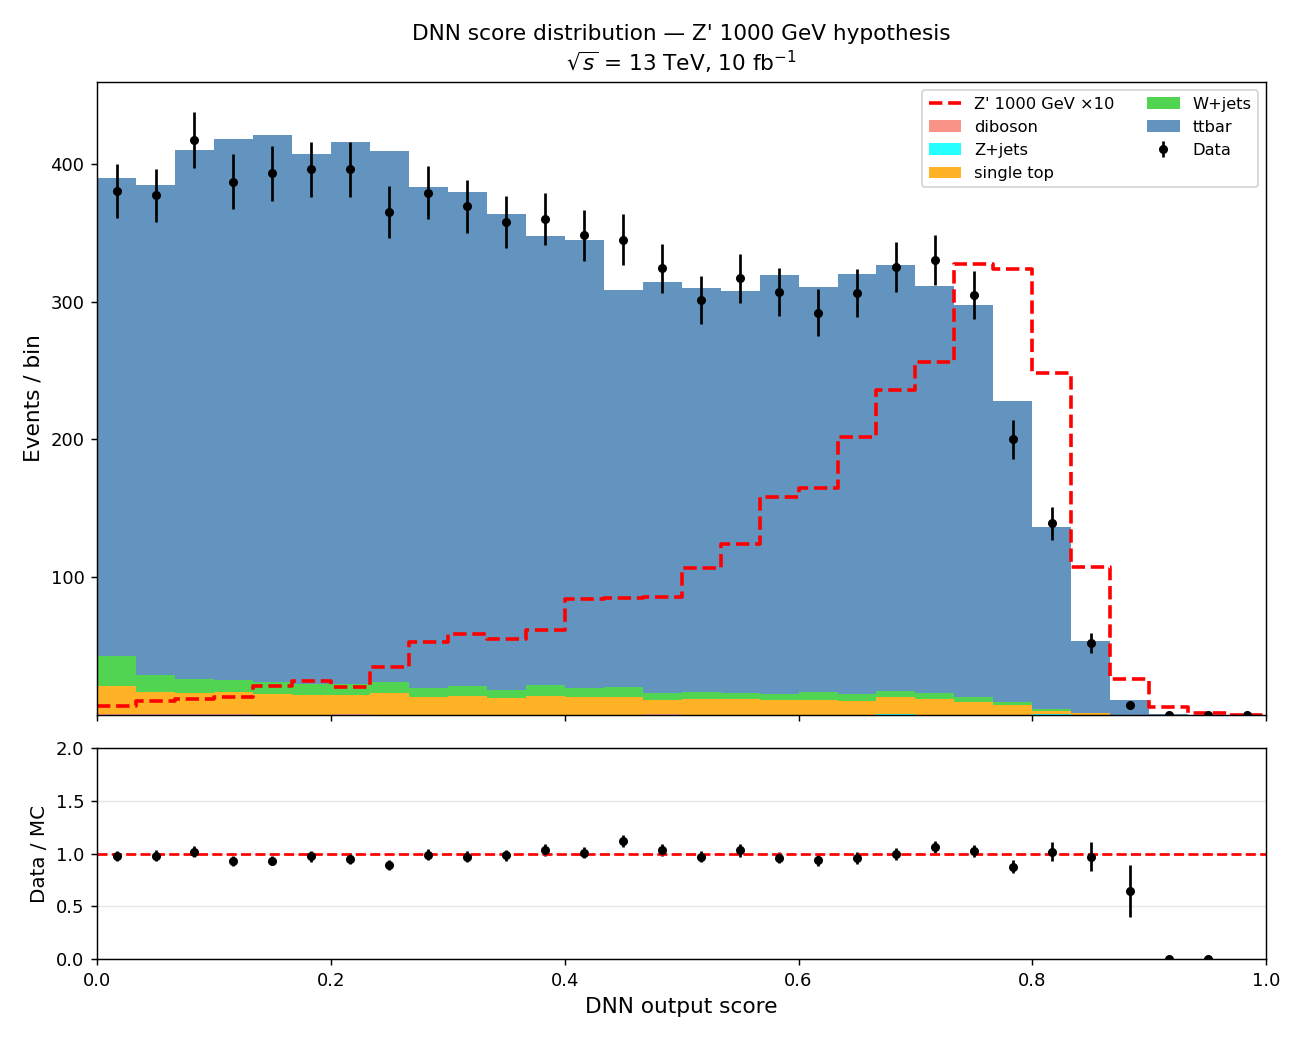

In [10]:
STACK_MASS   = 1000
STACK_COLORS = {
    "ttbar":      "steelblue",
    "W+jets":     "limegreen",
    "single top": "orange",
    "Z+jets":     "cyan",
    "diboson":    "salmon",
}

fig, (ax_main, ax_ratio) = plt.subplots(
    2, 1, figsize=(10, 8),
    gridspec_kw={"height_ratios": [3, 1]}, sharex=True
)

bin_centres = 0.5 * (SCORE_EDGES[:-1] + SCORE_EDGES[1:])
bin_width   = SCORE_EDGES[1] - SCORE_EDGES[0]

# build per-group stacked background
bkg_by_group = {}
for group, samples in BKG_SAMPLES.items():
    group_total = np.zeros(N_SCORE_BINS)
    for s in samples:
        scf  = SCALE_FACTORS.get(s, None)
        df_b = load_csv(s, scf)
        if df_b is None:
            continue
        if s == "ttbar_lep":
            df_b["weight"] *= 0.91
        scores_b, _ = make_score_hist(
            s, get_dnn_scores_for_sample(df_b, STACK_MASS),
            df_b["weight"].values, SCORE_EDGES
        )
        group_total += scores_b
    bkg_by_group[group] = group_total

stack_bottom   = np.zeros(N_SCORE_BINS)
bkg_total_hist = np.zeros(N_SCORE_BINS)
for group in ["diboson", "Z+jets", "single top", "W+jets", "ttbar"]:
    h = bkg_by_group.get(group, np.zeros(N_SCORE_BINS))
    ax_main.bar(bin_centres, h, width=bin_width, bottom=stack_bottom,
                color=STACK_COLORS[group], label=group, alpha=0.85)
    stack_bottom   += h
    bkg_total_hist += h

# signal overlay (×10 for visibility)
sig_h = dnn_sig_hists[STACK_MASS]
ax_main.step(SCORE_EDGES, np.append(sig_h, sig_h[-1]) * 10,
             where="post", color="red", lw=2, ls="--",
             label=f"Z' {STACK_MASS} GeV ×10")

# data
dat_h = dnn_dat_hists[STACK_MASS]
ax_main.errorbar(bin_centres, dat_h, yerr=np.sqrt(dat_h),
                 fmt="ko", ms=4, label="Data")

ax_main.set_ylabel("Events / bin", fontsize=12)
ax_main.set_title(f"DNN score distribution — Z' {STACK_MASS} GeV hypothesis\n"
                  r"$\sqrt{s}$ = 13 TeV, 10 fb$^{-1}$", fontsize=12)
ax_main.legend(fontsize=9, ncol=2)
ax_main.set_xlim(0, 1)

# ratio panel
ratio     = np.where(bkg_total_hist > 0, dat_h / bkg_total_hist, np.nan)
ratio_err = np.where(bkg_total_hist > 0, np.sqrt(dat_h) / bkg_total_hist, np.nan)
ax_ratio.errorbar(bin_centres, ratio, yerr=ratio_err, fmt="ko", ms=4)
ax_ratio.axhline(1.0, color="red", lw=1.5, ls="--")
ax_ratio.set_ylim(0, 2)
ax_ratio.set_xlabel("DNN output score", fontsize=12)
ax_ratio.set_ylabel("Data / MC", fontsize=11)
ax_ratio.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("dnn_score_stack.png", dpi=130)
plt.close()
display(Image("dnn_score_stack.png", width=800))

## 11. CLs Exclusion Fit (DNN observable)

Identical CLs scan to the baseline notebook (Sections 11–12) but using the
DNN score histogram as the fit observable instead of `hist_ttbarMLR`.

Two fits are run:

**Stat-only:** background is treated as exact. One signal strength parameter
$\mu$ floated per mass point. Fast (~2 min total).

**Barlow-Beeston:** one Gaussian-constrained nuisance parameter per bin with
width $ \delta b_i / b_i $, profiled during the scan. Slower but more correct.

$\mu$ < 1 $\rightarrow$ Z′ at this mass is **excluded** at 95% CL.

In [11]:
# stat-only 
print("Running DNN CLs scan — stat-only...\n")
print(f"  {'mass':>6}   {'obs mu<':>9}   {'exp mu<':>9}   status")
print("  " + "-"*46)

dnn_fit_results_statonly = {}
for mass in ALL_MASSES:
    if mass not in dnn_sig_hists:
        continue
    obs, exp_set = run_cls_fit_np(
        dnn_sig_hists[mass], dnn_bkg_hists[mass], dnn_dat_hists[mass],
        b_err_arr=None,
    )
    dnn_fit_results_statonly[mass] = {
        "obs": obs, "exp": exp_set[2],
        "exp_m2": exp_set[0], "exp_m1": exp_set[1],
        "exp_p1": exp_set[3], "exp_p2": exp_set[4],
    }
    tag = "  <- EXCLUDED" if obs < 1.0 else ""
    print(f"  {mass:>6}   {obs:>9.3f}   {exp_set[2]:>9.3f}{tag}")

#  Barlow-Beeston 
print("\nRunning DNN CLs scan — Barlow-Beeston...\n")
print(f"  {'mass':>6}   {'obs mu<':>9}   {'exp mu<':>9}   status")
print("  " + "-"*46)

dnn_fit_results_mcstat = {}
for mass in ALL_MASSES:
    if mass not in dnn_sig_hists:
        continue
    obs, exp_set = run_cls_fit_np(
        dnn_sig_hists[mass], dnn_bkg_hists[mass], dnn_dat_hists[mass],
        b_err_arr=dnn_bkg_errs[mass],
    )
    dnn_fit_results_mcstat[mass] = {
        "obs": obs, "exp": exp_set[2],
        "exp_m2": exp_set[0], "exp_m1": exp_set[1],
        "exp_p1": exp_set[3], "exp_p2": exp_set[4],
    }
    tag = "  <- EXCLUDED" if obs < 1.0 else ""
    print(f"  {mass:>6}   {obs:>9.3f}   {exp_set[2]:>9.3f}{tag}")

dnn_fit_results = dnn_fit_results_mcstat   # primary result
print("\nDone.")

Running DNN CLs scan — stat-only...

    mass     obs mu<     exp mu<   status
  ----------------------------------------------
     400       5.143      10.360
     500       4.065       5.471
     750       0.217       0.700  <- EXCLUDED
    1000       0.286       0.401  <- EXCLUDED
    1250       0.328       0.526  <- EXCLUDED
    1500       0.478       0.821  <- EXCLUDED
    1750       0.949       1.460  <- EXCLUDED
    2000       1.778       2.637
    2250       2.727       4.529
    2500       4.702       7.539
    2750       6.777      13.071
    3000      12.068      24.137

Running DNN CLs scan — Barlow-Beeston...

    mass     obs mu<     exp mu<   status
  ----------------------------------------------
     400       5.493      10.800
     500       4.277       5.700
     750       0.231       0.727  <- EXCLUDED
    1000       0.299       0.418  <- EXCLUDED
    1250       0.346       0.547  <- EXCLUDED
    1500       0.503       0.851  <- EXCLUDED
    1750       0.993       

/usr/local/lib/python3.9/site-packages/pyhf/infer/calculators.py:418: RuntimeWarning: divide by zero encountered in scalar divide
  teststat = (qmu - qmu_A) / (2 * self.sqrtqmuA_v)
/usr/local/lib/python3.9/site-packages/pyhf/infer/calculators.py:467: RuntimeWarning: invalid value encountered in divide
  CLs = tensorlib.astensor(CLsb / CLb)


    3000      12.536      24.653

Done.


## 12. Comparison: m_tt vs DNN

Side-by-side $\sigma$ x BR exclusion curves using the Barlow-Beeston fit for both observables. This is an apples-to-apples comparison: the same background model, same data, same fit machinery, only the observable changes.

The improvement comes from the DNN combining all 19 kinematic variables
simultaneously. The $m_{t \bar t}$ observable discards all information except the
reconstructed tt̄ invariant mass, while the DNN exploits lepton pT, MET,
$\tau_{32}$, large-R jet mass, b-jet kinematics, and their correlations.

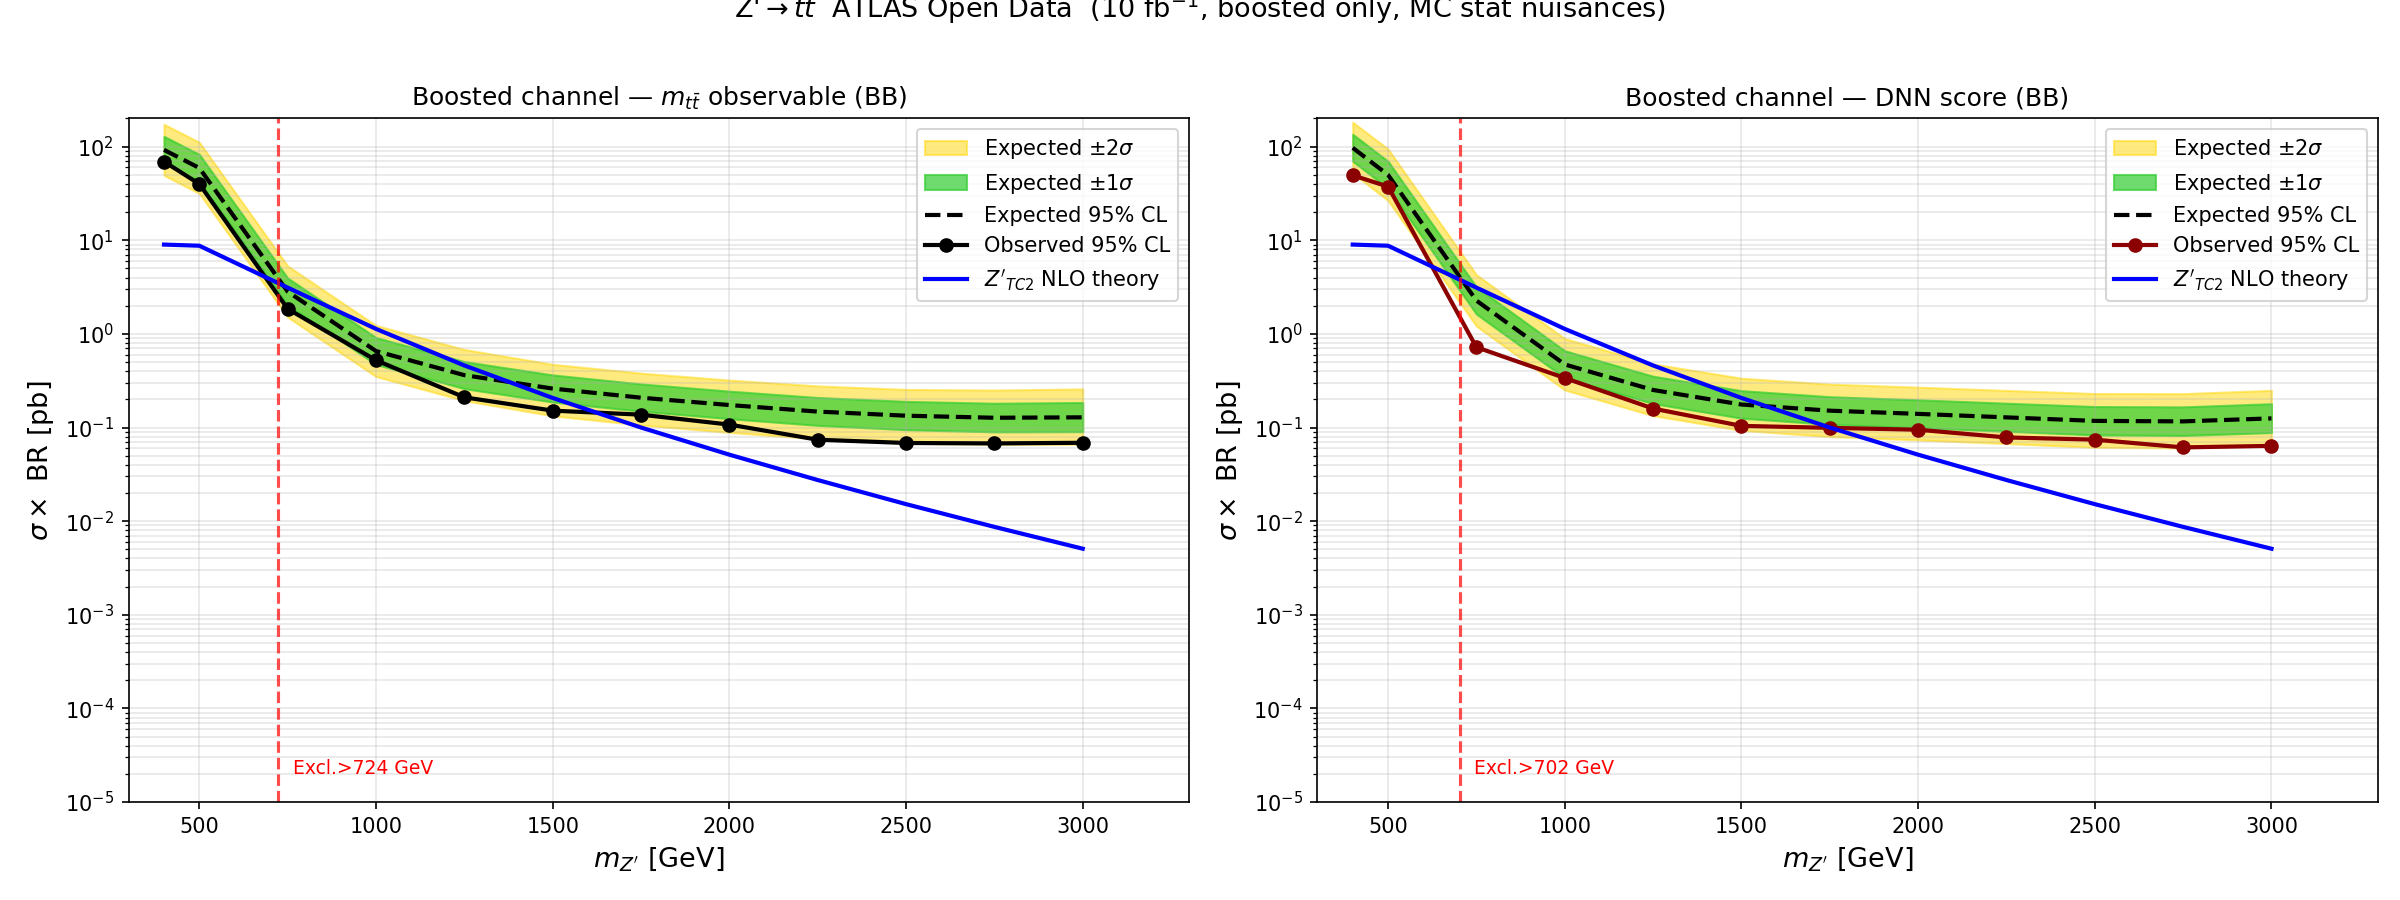

In [12]:
masses_arr  = np.array(sorted(dnn_fit_results_mcstat.keys()), dtype=float)
th_xsec_arr = np.array([theory_xsec[int(m)] for m in masses_arr])

dnn_obs = np.array([dnn_fit_results_mcstat[int(m)]["obs"]    for m in masses_arr])
dnn_exp = np.array([dnn_fit_results_mcstat[int(m)]["exp"]    for m in masses_arr])
dnn_m1  = np.array([dnn_fit_results_mcstat[int(m)]["exp_m1"] for m in masses_arr])
dnn_p1  = np.array([dnn_fit_results_mcstat[int(m)]["exp_p1"] for m in masses_arr])
dnn_m2  = np.array([dnn_fit_results_mcstat[int(m)]["exp_m2"] for m in masses_arr])
dnn_p2  = np.array([dnn_fit_results_mcstat[int(m)]["exp_p2"] for m in masses_arr])

mtt_obs = np.array([fit_results[int(m)]["obs"]    for m in masses_arr])
mtt_exp = np.array([fit_results[int(m)]["exp"]    for m in masses_arr])
mtt_m1  = np.array([fit_results[int(m)]["exp_m1"] for m in masses_arr])
mtt_p1  = np.array([fit_results[int(m)]["exp_p1"] for m in masses_arr])
mtt_m2  = np.array([fit_results[int(m)]["exp_m2"] for m in masses_arr])
mtt_p2  = np.array([fit_results[int(m)]["exp_p2"] for m in masses_arr])

# convert to sigma*BR
dnn_obs_xs = dnn_obs * th_xsec_arr;  dnn_exp_xs = dnn_exp * th_xsec_arr
dnn_m1_xs  = dnn_m1  * th_xsec_arr;  dnn_p1_xs  = dnn_p1  * th_xsec_arr
dnn_m2_xs  = dnn_m2  * th_xsec_arr;  dnn_p2_xs  = dnn_p2  * th_xsec_arr
mtt_obs_xs = mtt_obs * th_xsec_arr;  mtt_exp_xs = mtt_exp * th_xsec_arr
mtt_m1_xs  = mtt_m1  * th_xsec_arr;  mtt_p1_xs  = mtt_p1  * th_xsec_arr
mtt_m2_xs  = mtt_m2  * th_xsec_arr;  mtt_p2_xs  = mtt_p2  * th_xsec_arr

th_masses_line = np.array(sorted(theory_xsec.keys()), dtype=float)
th_xsec_line   = np.array([theory_xsec[int(m)] for m in th_masses_line])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, obs_xs, exp_xs, m1_xs, p1_xs, m2_xs, p2_xs, color in [
    (ax1, r"$m_{t\bar{t}}$ observable (BB)",
     mtt_obs_xs, mtt_exp_xs, mtt_m1_xs, mtt_p1_xs, mtt_m2_xs, mtt_p2_xs, "black"),
    (ax2, "DNN score (BB)",
     dnn_obs_xs, dnn_exp_xs, dnn_m1_xs, dnn_p1_xs, dnn_m2_xs, dnn_p2_xs, "darkred"),
]:
    ax.fill_between(masses_arr, m2_xs, p2_xs,
                    color="gold",      alpha=0.5, label=r"Expected $\pm2\sigma$")
    ax.fill_between(masses_arr, m1_xs, p1_xs,
                    color="limegreen", alpha=0.7, label=r"Expected $\pm1\sigma$")
    ax.semilogy(masses_arr, exp_xs, "k--", lw=2, label="Expected 95% CL")
    ax.semilogy(masses_arr, obs_xs, "o-",  lw=2, ms=6, color=color,
                label="Observed 95% CL")
    ax.semilogy(th_masses_line, th_xsec_line, "b-", lw=2,
                label=r"$Z'_{TC2}$ NLO theory")
    ax.set_xlabel(r"$m_{Z'}$ [GeV]", fontsize=13)
    ax.set_ylabel(r"$\sigma \times$ BR [pb]", fontsize=13)
    ax.set_title(f"Boosted channel — {label}", fontsize=12)
    ax.set_xlim(300, 3300)
    ax.set_ylim(1e-5, 200)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=10)

    try:
        ratio = interp1d(masses_arr, obs_xs / th_xsec_arr, kind="linear")
        scan  = np.linspace(masses_arr.min(), masses_arr.max(), 5000)
        cross = scan[:-1][np.diff(np.sign(ratio(scan) - 1.0)) != 0]
        if len(cross):
            ax.axvline(cross[0], color="red", lw=1.5, ls="--", alpha=0.7)
            ax.text(cross[0] + 40, 2e-5, f"Excl.>{cross[0]:.0f} GeV",
                    color="red", fontsize=9)
    except Exception:
        pass

plt.suptitle(
    r"Z'$\rightarrow t\bar{t}$  ATLAS Open Data  (10 fb$^{-1}$, boosted only, MC stat nuisances)",
    fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("comparison_mtt_vs_dnn.png", dpi=150)
plt.close()
display(Image("comparison_mtt_vs_dnn.png", width=1100))

## 13. Results Summary

### DNN fit results vs m_tt fit results

The improvement column shows the percentage reduction in the observed μ upper
limit relative to the m_tt baseline. A positive value means the DNN sets a
tighter limit, that is a stronger exclusion power.

### Improvement ratio

$\mu_{ m_{t \bar t}}$ / $\mu_{DNN}$ as a function of mass. Values > 1 mean the DNN is more sensitive.
The ratio quantifies the information gain from the multivariate approach and
is the most physics-relevant summary metric of this analysis.

### Expected exclusion lower limit

The mass at which the expected σ×BR limit crosses the theory line. Improvement
here means the DNN would exclude lower masses even with background-only data.

### AUC and significance

AUC measures pure discriminating power independent of luminosity. Max
significance gives the best achievable Asimov significance at the optimal DNN threshold.

  Comparison: m_tt (BB)  vs  DNN score (BB)
    mass     mtt obs     dnn obs    improvement    excl DNN
  ----------------------------------------------------------
     400 GeV       7.704       5.493        +28.7%          no
     500 GeV       4.562       4.277         +6.3%          no
     750 GeV       0.593       0.231        +61.1%         YES
    1000 GeV       0.463       0.299        +35.4%         YES
    1250 GeV       0.457       0.346        +24.2%         YES
    1500 GeV       0.732       0.503        +31.3%         YES
    1750 GeV       1.372       0.993        +27.7%         YES
    2000 GeV       2.096       1.847        +11.9%          no
    2250 GeV       2.695       2.850         -5.8%          no
    2500 GeV       4.499       4.883         -8.5%          no
    2750 GeV       7.786       7.061         +9.3%          no
    3000 GeV      13.532      12.536         +7.4%          no

  improvement = (mu_mtt - mu_DNN) / mu_mtt × 100%
  positive = DNN sets tighte

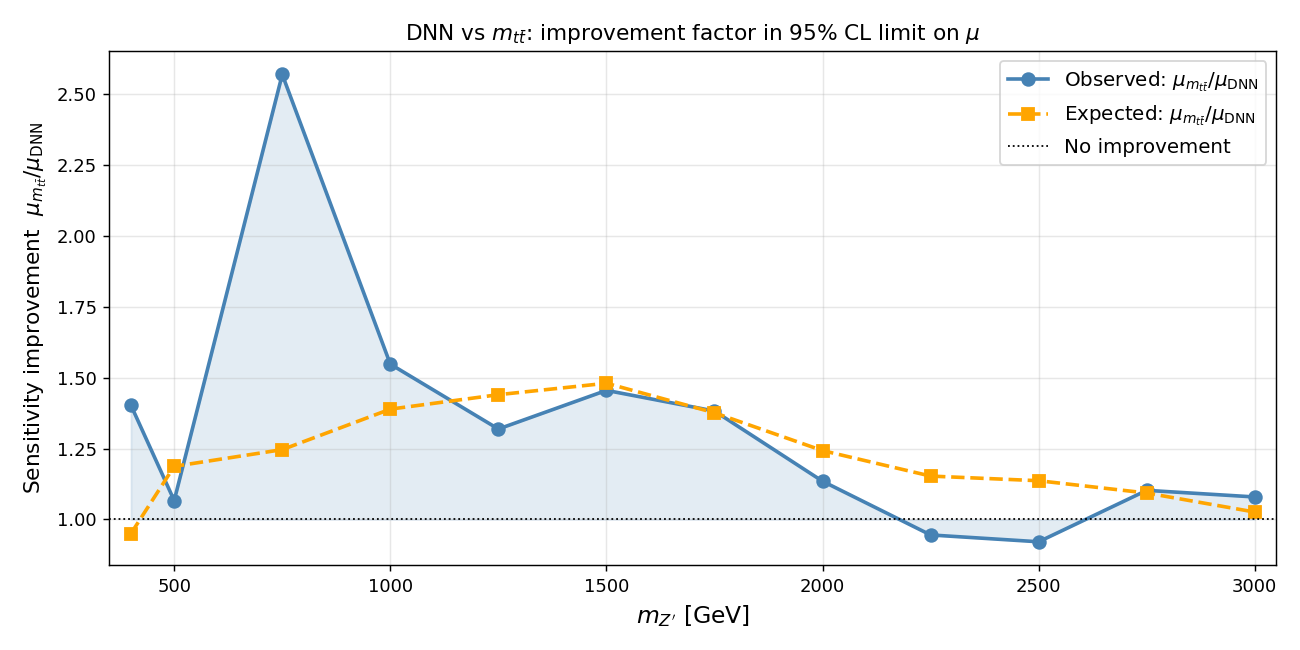

In [13]:
print("=" * 65)
print("  Comparison: m_tt (BB)  vs  DNN score (BB)")
print("=" * 65)
print(f"  {'mass':>6}   {'mtt obs':>9}   {'dnn obs':>9}   {'improvement':>12}   {'excl DNN':>9}")
print("  " + "-" * 58)

for m in masses_arr.astype(int):
    mtt_o = fit_results[m]["obs"]
    dnn_o = dnn_fit_results_mcstat[m]["obs"]
    impr  = (mtt_o - dnn_o) / mtt_o * 100 if mtt_o > 0 else float("nan")
    tag   = "YES" if dnn_o < 1.0 else "no"
    print(f"  {m:>6} GeV   {mtt_o:>9.3f}   {dnn_o:>9.3f}   {impr:>+10.1f}%   {tag:>9}")

print()
print("  improvement = (mu_mtt - mu_DNN) / mu_mtt × 100%")
print("  positive = DNN sets tighter limit = more sensitive")

print()
print("  Expected exclusion lower limit (where exp mu < 1):")
scan = np.linspace(masses_arr.min(), masses_arr.max(), 5000)

try:
    r_mtt = interp1d(masses_arr, mtt_exp, kind="linear")
    c_mtt = scan[:-1][np.diff(np.sign(r_mtt(scan) - 1.0)) != 0]
    print(f"    m_tt (BB)  : {c_mtt[0]:.0f} GeV" if len(c_mtt) else
          "    m_tt (BB)  : no crossing found")
except Exception as e:
    print(f"    m_tt (BB)  : {e}")

try:
    r_dnn = interp1d(masses_arr, dnn_exp, kind="linear")
    c_dnn = scan[:-1][np.diff(np.sign(r_dnn(scan) - 1.0)) != 0]
    print(f"    DNN (BB)   : {c_dnn[0]:.0f} GeV" if len(c_dnn) else
          "    DNN (BB)   : no crossing (all masses above threshold excluded)")
except Exception as e:
    print(f"    DNN (BB)   : {e}")

print()
print("  AUC and max significance per mass:\n")
print(f"  {'mass':>6}   {'AUC (test)':>10}   {'AUC (val)':>9}   {'max sig':>10}   {'epochs':>7}")
print("  " + "-" * 54)
for mass, r in results.items():
    print(f"  {mass:>6} GeV   {r['auc']:>10.4f}   {r['auc_val']:>9.4f}"
          f"   {r['max_sig']:>10.3f}   {len(r['history']['loss']):>7}")

# improvement ratio plot 
impr_obs = np.array([
    fit_results[m]["obs"] / dnn_fit_results_mcstat[m]["obs"]
    for m in masses_arr.astype(int)
])
impr_exp = np.array([
    fit_results[m]["exp"] / dnn_fit_results_mcstat[m]["exp"]
    for m in masses_arr.astype(int)
])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(masses_arr, impr_obs, "o-", lw=2, ms=7, color="steelblue",
        label=r"Observed: $\mu_{m_{t\bar{t}}} / \mu_\mathrm{DNN}$")
ax.plot(masses_arr, impr_exp, "s--", lw=2, ms=7, color="orange",
        label=r"Expected: $\mu_{m_{t\bar{t}}} / \mu_\mathrm{DNN}$")
ax.axhline(1.0, color="black", lw=1, ls=":", label="No improvement")
ax.fill_between(masses_arr, 1.0, impr_obs, alpha=0.15, color="steelblue")
ax.set_xlabel(r"$m_{Z'}$ [GeV]", fontsize=13)
ax.set_ylabel(r"Sensitivity improvement  $\mu_{m_{t\bar{t}}} / \mu_\mathrm{DNN}$",
              fontsize=12)
ax.set_title(r"DNN vs $m_{t\bar{t}}$: improvement factor in 95% CL limit on $\mu$",
             fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(350, 3050)
plt.tight_layout()
plt.savefig("sensitivity_improvement.png", dpi=130)
plt.close()
display(Image("sensitivity_improvement.png", width=900))